# 02 — Multimodal Features and Fusion
**SPJIMR ANA526-PPM | TALA Multimodal AI Strategy | Day 2 Task 2 + Task 2B**

**Purpose:** Freeze the validated Day 2 analytical datasets (`day2_verified_v1`), build
transparent text/visual/structured features, then (Task 2B) enrich with real YouTube
statistics, reassess partnership evidence from full video text, repair the content-intent
taxonomy, and make the cross-platform analytical boundary explicit.

**Scope for this notebook:** dataset freeze, media acquisition, feature construction,
YouTube metadata enrichment, descriptive (not causal) competitor analysis, explicit
modelling feasibility. **Fusion baselines, final RAG, and predictive modelling are
deliberately deferred** — see `notebooks/03_creator_strategy_and_claim_divergence.ipynb`
and `notebooks/04_multimodal_rag_and_evaluation.ipynb`.

**Prerequisites:** run these once from a terminal before executing this notebook top to bottom:
```
python scripts/freeze_day2_datasets.py
python scripts/collect_creator_media.py
python scripts/enrich_youtube_metrics.py
python scripts/build_multimodal_features.py
```</cell_id>


## 0. Setup and Imports

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display as ipy_display

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 100)
RANDOM_SEED = 42

PROCESSED = PROJECT_ROOT / "data" / "processed"
TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
MEDIA_DIR = PROJECT_ROOT / "data" / "media" / "creator_posts"

manifest = pd.read_csv(PROCESSED / "day2_dataset_manifest.csv")
snapshot = json.loads((PROCESSED / "day2_dataset_snapshot.json").read_text(encoding="utf-8"))
print("Dataset version:", snapshot["dataset_version"])
print("Frozen at:", snapshot["generated_at_utc"])
display(manifest[["path", "row_count", "unique_id_count", "duplicate_id_count", "validation_status", "sha256"]])

Dataset version: day2_verified_v1
Frozen at: 2026-09-18T10:28:07.141768+00:00


,path,row_count,unique_id_count,duplicate_id_count,validation_status,sha256
0,data/interim/day2/creator_posts_enriched.csv,65,65,0,PASS,f63f7b7b5ea8d1887b035a820cb96a6105aa4464b3ac37277c80a05698e95616
1,data/interim/day2/platform_strategy_enriched.csv,37,37,0,PASS,69b0c6d1274e770aaff7eb1156f895b4ab049e68c1579afb0f70e698f2e0c431
2,data/interim/day2/hydrated_sources.csv,244,244,0,PASS,8b3989ab31083c2d0d7b4489810dacbe4fc0ca8db5c3a9de82b0cff7d10d444d
3,data/corpora/official_claims_corpus.csv,37,37,0,PASS,f75b984dd2802579b226e9c8e0a3e8102af7097e33bc29bc98cff1806d378e1c
4,data/corpora/customer_experience_corpus.csv,95,95,0,PASS,162fc9665eb7b047a73f77802ca15afd9af755cfdd7e3adccc5f39258bbb2901
5,data/corpora/creator_strategy_corpus.csv,61,61,0,PASS,395b32f7612ae0e67d939d4d494903b5ac080833872879a286cc994b465689fa


## 1. Analytical Dataset and Evidence Filters

Every feature table downstream is built ONLY from `strong`/`medium` evidence-strength rows of
the six frozen Day 2 files — never raw DDG/search leads, and never `weak`/`unusable` rows.
`src/validation.py::assert_evidence_strength_allowed()` enforces this as a hard gate at write time
(see `scripts/build_multimodal_features.py`) — a weak/unusable row raises, it is never silently dropped.

In [2]:
creator_feat = pd.read_csv(PROCESSED / "creator_multimodal_features.csv")
customer_feat = pd.read_csv(PROCESSED / "customer_text_features.csv")
claims_feat = pd.read_csv(PROCESSED / "official_claim_features.csv")
platform_feat = pd.read_csv(PROCESSED / "platform_strategy_features.csv")

for name, df in [("creator_multimodal_features", creator_feat), ("customer_text_features", customer_feat),
                  ("official_claim_features", claims_feat), ("platform_strategy_features", platform_feat)]:
    strengths = df["evidence_strength"].value_counts().to_dict()
    assert set(strengths) <= {"strong", "medium"}, f"{name} leaked weak/unusable evidence!"
    print(f"  {name:<32} {len(df):>4} rows  evidence_strength={strengths}")

  creator_multimodal_features        61 rows  evidence_strength={'strong': 61}
  customer_text_features             95 rows  evidence_strength={'strong': 56, 'medium': 39}
  official_claim_features            37 rows  evidence_strength={'strong': 37}
  platform_strategy_features         31 rows  evidence_strength={'strong': 25, 'medium': 6}


## 2. Creator Coverage by Brand and Platform

Total verified creator posts (n=61):


,brand,verified_posts,platforms_used,disclosure_rate_pct,sustainability_mention_rate_pct,sample_size_denominator
0,Adanola,16,2,81.2,18.8,61
1,Girlfriend Collective,13,1,76.9,69.2,61
2,Oner Active,8,1,37.5,0.0,61
3,TALA,24,1,20.8,33.3,61


,platform,verified_posts,brands_present,pct_of_all_verified_posts,sample_size_denominator
0,tiktok,1,1,1.6,61
1,youtube,60,4,98.4,61


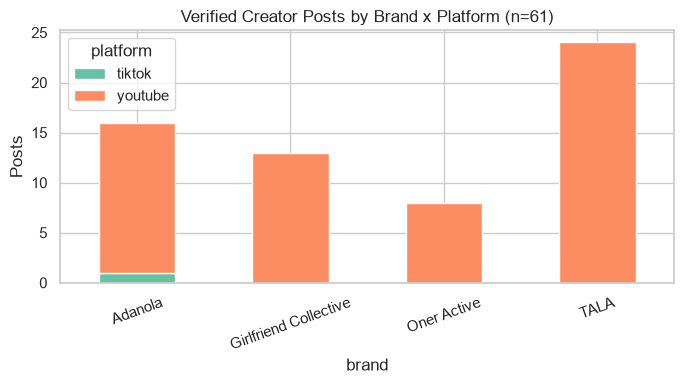

In [3]:
by_brand = pd.read_csv(TABLES / "day2_creator_strategy_by_brand.csv")
by_platform = pd.read_csv(TABLES / "day2_creator_strategy_by_platform.csv")
n_total = len(creator_feat)

print(f"Total verified creator posts (n={n_total}):")
display(by_brand)
display(by_platform)

fig, ax = plt.subplots(figsize=(7, 4))
creator_feat.groupby(["brand", "platform"]).size().unstack(fill_value=0).plot(
    kind="bar", stacked=True, ax=ax, color=sns.color_palette("Set2", creator_feat["platform"].nunique()))
ax.set_title(f"Verified Creator Posts by Brand x Platform (n={n_total})")
ax.set_ylabel("Posts")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 3. Text-Feature Construction

Deterministic, rule-based features (`src/text_features.py`, keywords in `configs/feature_rules.yaml`)
— general stats + creator-strategy indicators for creator posts; term-frequency categories for
customer reviews; numerical/certification/material indicators for official claims.

Creator post text features (sample):


,post_id,brand,word_count,hashtag_count,sentiment_score,disclosure_indicator,discount_code_indicator,sustainability_responsibility_indicator
0,CP_0008,TALA,260,16,0.3274,False,False,True
1,CP_0009,TALA,58,11,0.3115,False,False,False
2,CP_0010,TALA,76,6,-0.0067,False,False,False
3,CP_0012,TALA,115,3,0.2229,False,False,False
4,CP_0020,Adanola,132,0,0.0704,True,False,False
5,CP_0024,Adanola,14,5,0.0000,True,False,False
6,CP_0026,Girlfriend Collective,124,0,0.1267,True,False,True
7,creator_enriched_0001,TALA,111,0,0.3170,False,False,True



Customer review term-frequency features (sample):


,document_id,brand,quality_term_frequency,fit_sizing_term_frequency,delivery_term_frequency,review_polarity
0,ce_rev_0001,TALA,0,0,0,positive
1,ce_rev_0002,TALA,7,13,0,positive
2,ce_rev_0003,TALA,1,1,0,positive
3,ce_rev_0004,TALA,1,14,4,positive
4,ce_rev_0005,TALA,0,0,0,positive
5,ce_rev_0006,TALA,0,0,0,positive
6,ce_rev_0007,TALA,0,0,0,positive
7,ce_rev_0008,TALA,0,0,0,positive



Official claim indicator features (sample):


,document_id,brand,numerical_claim_indicator,percentage_indicator,certification_indicator,material_indicator
0,oc_0001,TALA,False,False,False,False
1,oc_0002,TALA,False,False,False,False
2,oc_0003,TALA,False,False,False,True
3,oc_0004,TALA,False,False,False,True
4,oc_0005,TALA,False,False,False,False
5,oc_0006,TALA,False,False,False,False
6,oc_0007,TALA,False,False,False,False
7,oc_0008,TALA,False,False,False,False


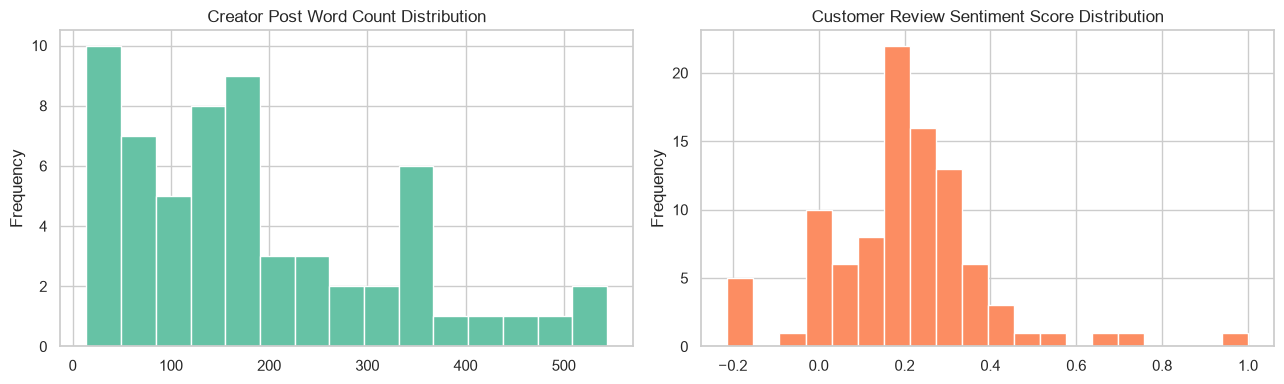

In [4]:
print("Creator post text features (sample):")
display(creator_feat[["post_id", "brand", "word_count", "hashtag_count", "sentiment_score",
                       "disclosure_indicator", "discount_code_indicator", "sustainability_responsibility_indicator"]].head(8))

print("\nCustomer review term-frequency features (sample):")
display(customer_feat[["document_id", "brand", "quality_term_frequency", "fit_sizing_term_frequency",
                        "delivery_term_frequency", "review_polarity"]].head(8))

print("\nOfficial claim indicator features (sample):")
display(claims_feat[["document_id", "brand", "numerical_claim_indicator", "percentage_indicator",
                      "certification_indicator", "material_indicator"]].head(8))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
creator_feat["word_count"].plot(kind="hist", bins=15, ax=axes[0], color=sns.color_palette("Set2")[0])
axes[0].set_title("Creator Post Word Count Distribution")
customer_feat["sentiment_score"].plot(kind="hist", bins=20, ax=axes[1], color=sns.color_palette("Set2")[1])
axes[1].set_title("Customer Review Sentiment Score Distribution")
plt.tight_layout()
plt.show()

## 4. Media-Acquisition Funnel

One public representative thumbnail per verified post, tried in order: cached oEmbed thumbnail →
Open Graph image → YouTube's public thumbnail endpoint → unavailable. No login bypass, no full
video downloads, no private content.

Media acquisition: 61 verified posts attempted
retrieval_status
success        60
unavailable     1

By platform:
platform  retrieval_status
tiktok    unavailable          1
youtube   success             60

By method (successful only):
retrieval_method
cached_oembed_thumbnail    60


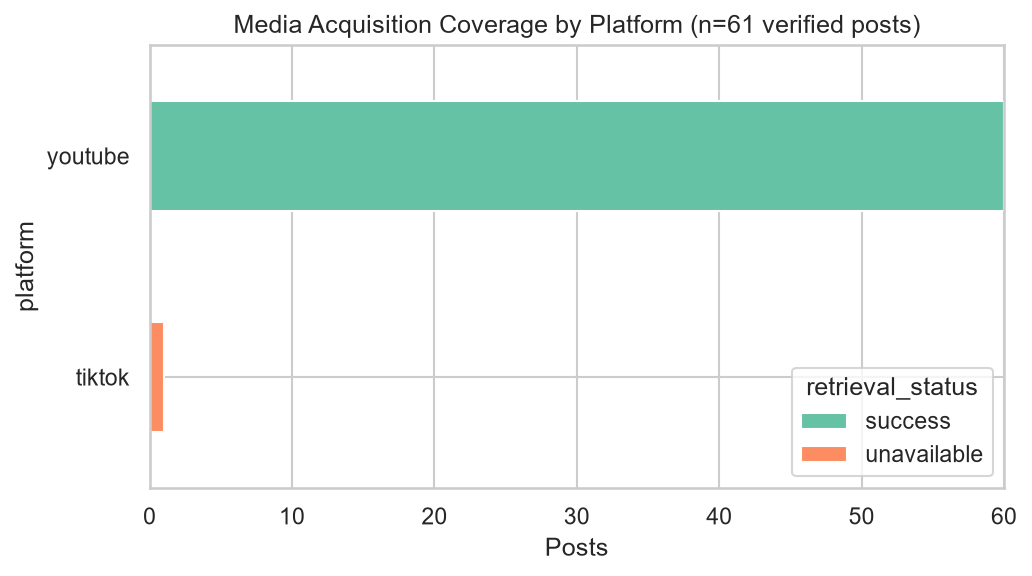

In [5]:
media = pd.read_csv(PROCESSED / "creator_media_manifest.csv")
print(f"Media acquisition: {len(media)} verified posts attempted")
print(media["retrieval_status"].value_counts().to_string())
print("\nBy platform:")
print(media.groupby(["platform", "retrieval_status"]).size().to_string())
print("\nBy method (successful only):")
print(media[media["retrieval_status"] == "success"]["retrieval_method"].value_counts().to_string())

img = FIGURES / "day2_media_coverage.png"
if img.exists():
    ipy_display(Image(str(img), width=650))

## 5. Visual-Feature Examples

Interpretable stats only (brightness/contrast/saturation/edge density/colour group + weak labels).
No face embeddings retained, no protected-characteristic inference. CLIP embeddings (512-dim,
pretrained `openai/clip-vit-base-patch32`, CPU, never fine-tuned) are cached separately under
`data/processed/embeddings/clip/` and indexed, never inlined in the feature CSV.

Rows with acquired visual features: 60/61


,post_id,brand,width,height,mean_brightness,contrast,saturation,dominant_color_group,edge_density,studio_or_lifestyle_label,screenshot_or_meme_indicator,embedding_available
0,CP_0008,TALA,480.0,360.0,82.53,67.54,41.52,orange,0.0567,studio,False,True
1,CP_0009,TALA,480.0,360.0,88.01,66.51,61.43,greyscale,0.0438,lifestyle,False,True
2,CP_0010,TALA,480.0,360.0,130.42,95.66,33.62,greyscale,0.0881,studio,False,True
3,CP_0012,TALA,480.0,360.0,80.74,74.06,38.99,greyscale,0.0631,studio,False,True
4,CP_0020,Adanola,480.0,360.0,113.61,88.09,56.11,greyscale,0.0461,studio,False,True
6,CP_0026,Girlfriend Collective,480.0,360.0,108.68,96.09,49.69,greyscale,0.0731,studio,False,True
7,creator_enriched_0001,TALA,480.0,360.0,138.68,90.52,49.30,orange,0.0287,studio,False,True
8,creator_enriched_0002,TALA,480.0,360.0,86.36,71.74,66.93,orange,0.0862,studio,False,True



CLIP embeddings cached: 60


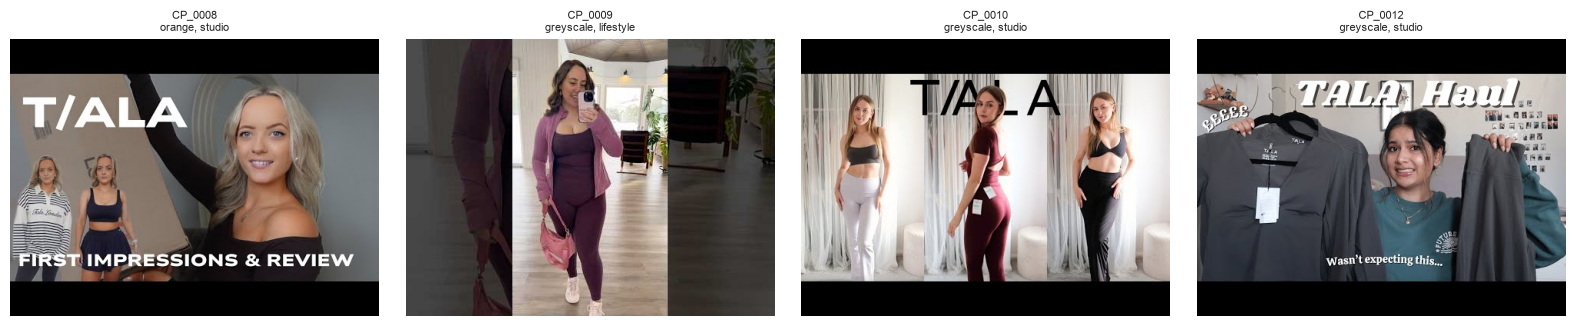


Person-detection limitation: person_or_product_label is 'unknown' for all rows -- this environment's opencv-python build (5.0.0) does not expose CascadeClassifier (confirmed via dir(cv2)). Not substituted with a skin-tone heuristic (would introduce racial bias). See src/collectors/../image_features.py::person_present_weak_label docstring.
person_or_product_label
unknown    60
NaN         1


In [6]:
visual_cols = ["post_id", "brand", "width", "height", "mean_brightness", "contrast", "saturation",
               "dominant_color_group", "edge_density", "studio_or_lifestyle_label",
               "screenshot_or_meme_indicator", "embedding_available"]
have_visual = creator_feat[creator_feat["mean_brightness"].notna()]
print(f"Rows with acquired visual features: {len(have_visual)}/{len(creator_feat)}")
display(have_visual[visual_cols].head(8))

emb_index = pd.read_csv(PROCESSED / "embeddings" / "clip_embedding_index.csv")
print(f"\nCLIP embeddings cached: {len(emb_index)}")

sample_posts = have_visual["post_id"].head(4).tolist()
fig, axes = plt.subplots(1, len(sample_posts), figsize=(4 * len(sample_posts), 3.2))
for ax, pid in zip(axes, sample_posts):
    row = creator_feat[creator_feat["post_id"] == pid].iloc[0]
    p = PROJECT_ROOT / row["media_path"]
    if p.exists():
        img = plt.imread(p)
        ax.imshow(img)
    ax.set_title(f"{pid}\n{row['dominant_color_group']}, {row['studio_or_lifestyle_label']}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("\nPerson-detection limitation: person_or_product_label is 'unknown' for all rows -- "
      "this environment's opencv-python build (5.0.0) does not expose CascadeClassifier "
      "(confirmed via dir(cv2)). Not substituted with a skin-tone heuristic (would introduce "
      "racial bias). See src/collectors/../image_features.py::person_present_weak_label docstring.")
print(creator_feat["person_or_product_label"].value_counts(dropna=False).to_string())

## 6. Partnership Mix (Revised — Task 2B Part C)

`revised_partnership_type` is reassessed from the FULL YouTube video title + description
(not a truncated caption snippet), against explicit disclosure phrases only — a bare brand
mention is never sufficient (see `src/collectors/creator_identity.py::reassess_partnership`).
`original_partnership_type` (Task 2's classification, based on the shorter caption) is kept
for comparison. Percentages always show their brand-level denominator (`brand_total`).</cell_id>


,brand,revised_partnership_type,count,brand_total,pct_within_brand,sample_size_denominator
0,Adanola,affiliate,4,16,25.0,61
1,Adanola,gifted,1,16,6.2,61
2,Adanola,organic,3,16,18.8,61
3,Adanola,paid_sponsorship,8,16,50.0,61
4,Girlfriend Collective,affiliate,8,13,61.5,61
5,Girlfriend Collective,gifted,1,13,7.7,61
6,Girlfriend Collective,organic,4,13,30.8,61
7,Oner Active,affiliate,1,8,12.5,61
8,Oner Active,organic,7,8,87.5,61
9,TALA,affiliate,3,24,12.5,61


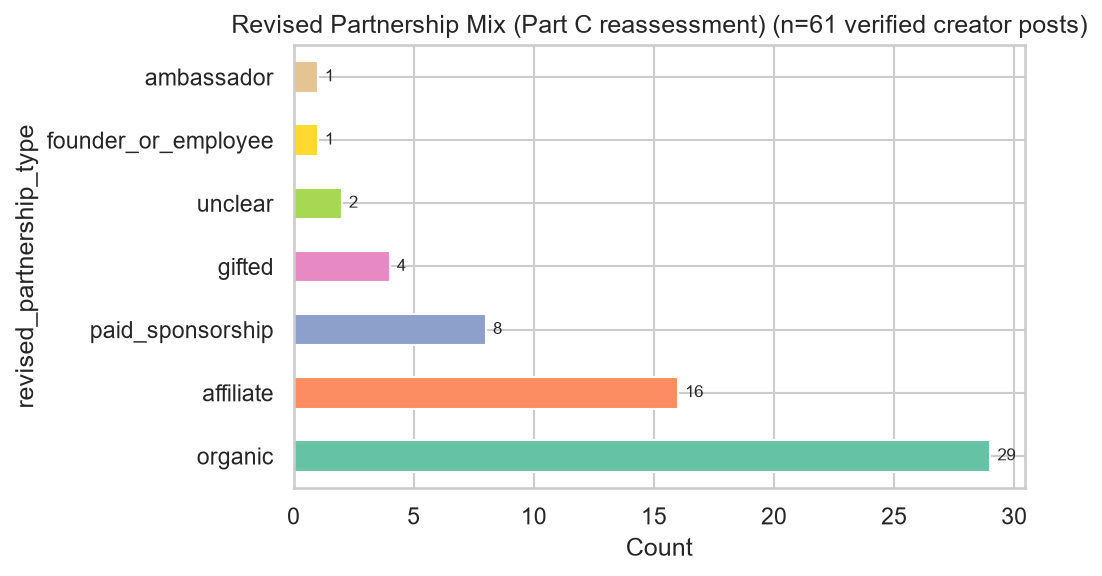


Original (Task 2, caption-only) vs revised (Task 2B, full title+description) comparison:


revised_partnership_type,affiliate,ambassador,founder_or_employee,gifted,organic,paid_sponsorship,unclear
original_partnership_type,,,,,,,
founder_or_employee,0,0,1,0,0,0,0
gifted,0,0,0,2,0,0,0
organic,16,0,0,2,29,3,0
paid_sponsorship,0,0,0,0,0,5,0
unclear,0,1,0,0,0,0,2


22/61 rows changed classification once the full video description was used.

Observed pattern (descriptive only -- not a causal or 'moat' claim at this stage):
revised_partnership_type  affiliate  ambassador  founder_or_employee  gifted  \
brand                                                                          
Adanola                        25.0         0.0                  0.0     6.2   
Girlfriend Collective          61.5         0.0                  0.0     7.7   
Oner Active                    12.5         0.0                  0.0     0.0   
TALA                           12.5         4.2                  4.2     8.3   

revised_partnership_type  organic  paid_sponsorship  unclear  
brand                                                         
Adanola                      18.8              50.0      0.0  
Girlfriend Collective        30.8               0.0      0.0  
Oner Active                  87.5               0.0      0.0  
TALA                         62.5           

In [7]:
partnership_mix = pd.read_csv(TABLES / "day2_partnership_mix.csv")
display(partnership_mix)

img = FIGURES / "day2_revised_partnership_mix.png"
if img.exists():
    ipy_display(Image(str(img), width=650))

print("\nOriginal (Task 2, caption-only) vs revised (Task 2B, full title+description) comparison:")
compare = pd.crosstab(creator_feat["original_partnership_type"], creator_feat["revised_partnership_type"])
display(compare)
n_changed = int((creator_feat["original_partnership_type"] != creator_feat["revised_partnership_type"]).sum())
print(f"{n_changed}/{len(creator_feat)} rows changed classification once the full video description was used.")

print("\nObserved pattern (descriptive only -- not a causal or 'moat' claim at this stage):")
print(partnership_mix.pivot_table(index="brand", columns="revised_partnership_type", values="pct_within_brand", fill_value=0))

## 7. Content-Intent Mix — Revised Primary + Multi-Label (Task 2B Part D)

Task 2's single forced-choice classifier put 47/61 (77%) posts in `mixed` — not analytically
useful. Task 2B replaces it: 9 boolean `intent_<category>` indicators plus one `primary_intent`
(title matches weighted 2x over description matches; `mixed` is now reserved for a genuine
top-score TIE, not the default whenever 2+ categories match at all). `original_intent_weak_label`
(Task 2's label) is kept for comparison. Still a WEAK label —
`requires_human_validation=True` on every row, `label_source=automated_weak_label`. See
`docs/content_intent_codebook.md`.</cell_id>


,brand,primary_intent,count,brand_total,pct_within_brand,sample_size_denominator
0,Adanola,product_demonstration,16,16,100.0,61
1,Girlfriend Collective,mixed,4,13,30.8,61
2,Girlfriend Collective,product_demonstration,6,13,46.2,61
3,Girlfriend Collective,responsibility,1,13,7.7,61
4,Girlfriend Collective,review,2,13,15.4,61
5,Oner Active,mixed,3,8,37.5,61
6,Oner Active,product_demonstration,4,8,50.0,61
7,Oner Active,review,1,8,12.5,61
8,TALA,mixed,1,24,4.2,61
9,TALA,product_demonstration,18,24,75.0,61


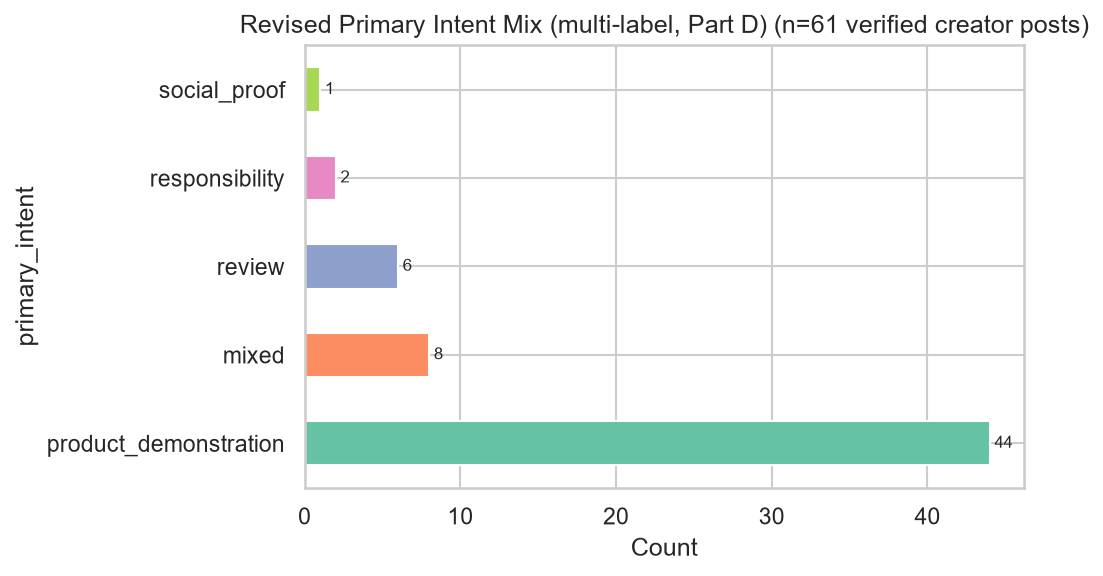

Original (Task 2, forced single-label) vs revised primary_intent:
  original 'mixed' rate: 77% (47/61)
  revised  'mixed' rate: 13% (8/61)

Multi-label indicator prevalence (n=61):
intent_product_demonstration    59
intent_review                   45
intent_responsibility           20
intent_education                16
intent_conversion               11
intent_social_proof              3
intent_awareness                 1
intent_product_launch            0
intent_community                 0

Human-validation sample: 61 records (target ~80, capped by 61 eligible)
Coder fields left blank for human coding: {'coder_1_label': True, 'coder_2_label': True, 'adjudicated_label': True}
brand
TALA                     24
Adanola                  16
Girlfriend Collective    13
Oner Active               8


In [8]:
intent_mix = pd.read_csv(TABLES / "day2_content_intent_mix.csv")
display(intent_mix)

img = FIGURES / "day2_revised_primary_intent_mix.png"
if img.exists():
    ipy_display(Image(str(img), width=650))

print("Original (Task 2, forced single-label) vs revised primary_intent:")
print(f"  original 'mixed' rate: {(creator_feat['original_intent_weak_label']=='mixed').mean():.0%} "
      f"({int((creator_feat['original_intent_weak_label']=='mixed').sum())}/{len(creator_feat)})")
print(f"  revised  'mixed' rate: {(creator_feat['primary_intent']=='mixed').mean():.0%} "
      f"({int((creator_feat['primary_intent']=='mixed').sum())}/{len(creator_feat)})")

intent_cols = [c for c in creator_feat.columns if c.startswith("intent_")]
print(f"\nMulti-label indicator prevalence (n={len(creator_feat)}):")
print(creator_feat[intent_cols].sum().sort_values(ascending=False).to_string())

sample = pd.read_csv(PROJECT_ROOT / "data" / "manual_labels" / "content_intent_validation_sample.csv")
print(f"\nHuman-validation sample: {len(sample)} records (target ~80, capped by {len(creator_feat)} eligible)")
print("Coder fields left blank for human coding:", sample[["coder_1_label", "coder_2_label", "adjudicated_label"]].isna().all().to_dict())
print(sample["brand"].value_counts().to_string())

## 7b. YouTube API Metadata Coverage (Task 2B Part A)

Real video/channel statistics via YouTube Data API v3 (`videos.list` + `channels.list`,
batched at <=50 IDs, cached under `data/cache/youtube_api/`, gitignored). The API key is
read from `.env` and never printed/logged/committed. Missing/hidden statistics stay `NaN`,
never fabricated as 0.

In [9]:
yt_videos = pd.read_csv(PROCESSED / "youtube_video_metrics.csv")
yt_channels = pd.read_csv(PROCESSED / "youtube_channel_metrics.csv")

n_yt_verified = int((creator_feat["platform"] == "youtube").sum())
n_video_success = int((yt_videos["api_retrieval_status"] == "success").sum())
print(f"YouTube videos requested: {len(yt_videos)} (of {n_yt_verified} verified YouTube posts)")
print(f"Successfully enriched: {n_video_success}/{len(yt_videos)}")
if n_video_success < len(yt_videos):
    display(yt_videos.loc[yt_videos["api_retrieval_status"] != "success", ["video_id", "api_retrieval_status", "api_failure_reason"]])

print(f"\nChannels requested: {yt_videos['channel_id'].nunique()} unique")
print(f"Channel statistics retrieved: {len(yt_channels)}")
n_hidden = int(yt_channels["hidden_subscriber_count"].sum())
print(f"Channels with hidden subscriber count: {n_hidden}")

print("\nStatistic coverage on verified rows:")
for col in ("view_count", "like_count", "comment_count", "channel_subscriber_count_current"):
    n_present = int(creator_feat[col].notna().sum())
    print(f"  {col:<38} {n_present}/{len(creator_feat)}")

print("\nCAVEAT: channel_subscriber_count_current is a RETRIEVAL-TIME snapshot -- "
      "not the subscriber count on each video's historical post date. "
      "subscriber_count_is_historical is always False in this table.")
assert (creator_feat["subscriber_count_is_historical"] == False).all()

YouTube videos requested: 60 (of 60 verified YouTube posts)
Successfully enriched: 60/60

Channels requested: 49 unique
Channel statistics retrieved: 49
Channels with hidden subscriber count: 0

Statistic coverage on verified rows:
  view_count                             60/61
  like_count                             60/61
  comment_count                          60/61
  channel_subscriber_count_current       60/61

CAVEAT: channel_subscriber_count_current is a RETRIEVAL-TIME snapshot -- not the subscriber count on each video's historical post date. subscriber_count_is_historical is always False in this table.


## 8. Normalised Engagement Availability (Task 2B Part B)

**Metric definitions:** `engagement_count = like_count + comment_count`; `interaction_rate_by_views
= engagement_count / view_count`; `like_rate_by_views`, `comment_rate_by_views` analogous;
`engagement_rate_by_current_subscribers = engagement_count / channel_subscriber_count_current`.
All divisions return `NaN` rather than raising or substituting 0 when the denominator is missing
or zero. `within_channel_engagement_zscore`/`percentile` are computed ONLY for channels with
>=3 verified posts (`within_channel_normalisation_eligible`) — never substituted with a
brand-level value under the same name; a separately-named `descriptive_brand_engagement_percentile`
exists for that broader (weaker) comparison.</cell_id>


,metric,n_verified_posts,n_with_metric,pct_with_metric,modelling_decision,subscriber_count_caveat
0,view_count,61,60,98.4,GO,"channel_subscriber_count_current is a RETRIEVAL-TIME snapshot, not the historical subscriber cou..."
1,like_count,61,60,98.4,GO,"channel_subscriber_count_current is a RETRIEVAL-TIME snapshot, not the historical subscriber cou..."
2,comment_count,61,60,98.4,GO,"channel_subscriber_count_current is a RETRIEVAL-TIME snapshot, not the historical subscriber cou..."
3,channel_subscriber_count_current,61,60,98.4,GO,"channel_subscriber_count_current is a RETRIEVAL-TIME snapshot, not the historical subscriber cou..."
4,engagement_count (like+comment both present),61,60,98.4,GO,"channel_subscriber_count_current is a RETRIEVAL-TIME snapshot, not the historical subscriber cou..."
5,interaction_rate_by_views,61,60,98.4,GO,"channel_subscriber_count_current is a RETRIEVAL-TIME snapshot, not the historical subscriber cou..."
6,engagement_rate_by_current_subscribers,61,60,98.4,GO,"channel_subscriber_count_current is a RETRIEVAL-TIME snapshot, not the historical subscriber cou..."
7,within_channel_normalisation_eligible (channels with >=3 posts: 3),61,9,14.8,GO,"channel_subscriber_count_current is a RETRIEVAL-TIME snapshot, not the historical subscriber cou..."



Engagement modelling decision: GO
60/61 verified posts have a real engagement_count (>= 30 threshold).
Within-channel-normalisation-eligible: 9 rows across 3 channels (each with >=3 posts).
channel_subscriber_count_current is a RETRIEVAL-TIME snapshot, not the historical subscriber count on the post date


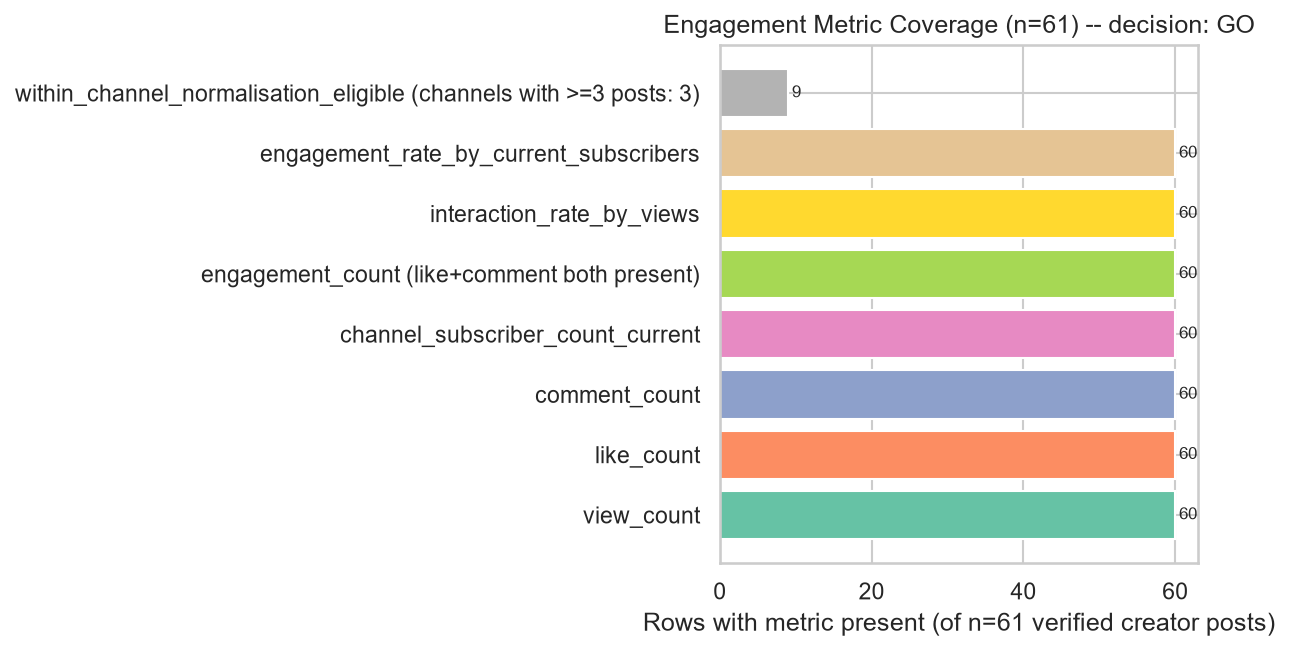

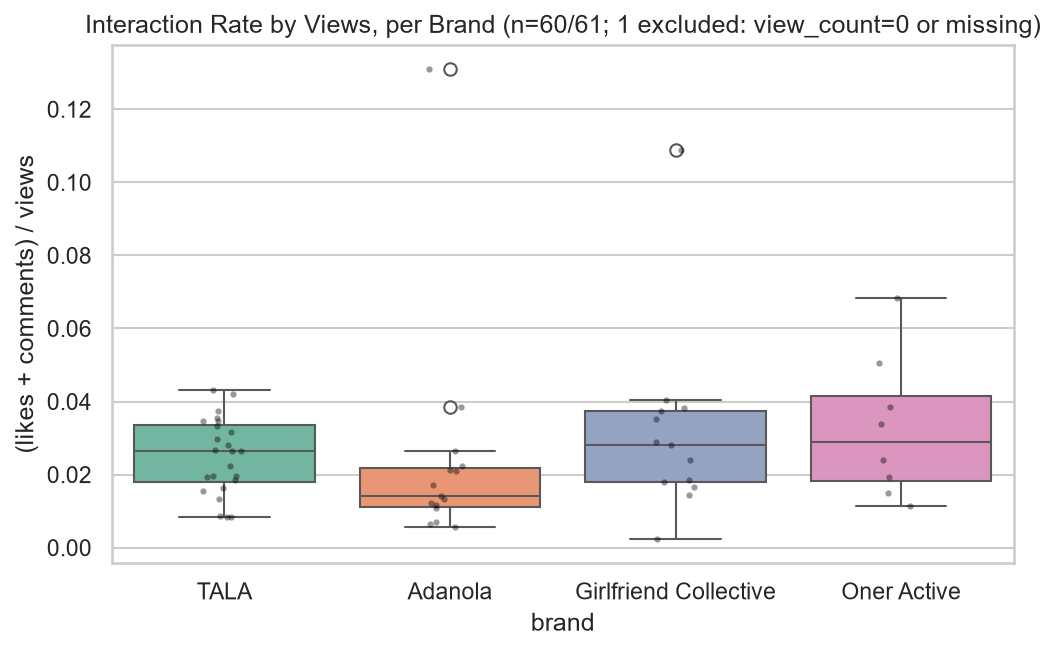


Within-channel z-scores (eligible channels only, n=3 channels):


,post_id,channel_title,engagement_count,within_channel_engagement_zscore,within_channel_engagement_percentile,posts_from_channel_in_sample
1,CP_0009,Jamie Leigh Gagnon,112.0,1.2808,1.0000,3
8,creator_enriched_0002,Naomi | Fitness,96.0,0.4319,0.6667,3
13,creator_enriched_0007,Naomi | Fitness,26.0,-1.3822,0.3333,3
14,creator_enriched_0008,Jamie Leigh Gagnon,65.0,-1.1597,0.3333,3
35,creator_enriched_0029,Janice Eadie,52.0,-0.4047,0.6667,3
36,creator_enriched_0030,Janice Eadie,45.0,-0.9712,0.3333,3
39,creator_enriched_0033,Janice Eadie,74.0,1.3759,1.0000,3
51,creator_enriched_0049,Jamie Leigh Gagnon,85.0,-0.1212,0.6667,3
55,creator_enriched_0053,Naomi | Fitness,116.0,0.9503,1.0000,3


In [10]:
engagement_cov = pd.read_csv(TABLES / "day2_engagement_coverage.csv")
display(engagement_cov)

decision = engagement_cov["modelling_decision"].iloc[0]
n_eng = int(creator_feat["engagement_count"].notna().sum())
n_channel_eligible_rows = int(creator_feat["within_channel_normalisation_eligible"].sum())
n_channels_eligible = creator_feat.loc[creator_feat["within_channel_normalisation_eligible"], "channel_id"].nunique()

print(f"\nEngagement modelling decision: {decision}")
print(f"{n_eng}/{len(creator_feat)} verified posts have a real engagement_count (>= 30 threshold).")
print(f"Within-channel-normalisation-eligible: {n_channel_eligible_rows} rows across {n_channels_eligible} channels (each with >=3 posts).")
print(engagement_cov["subscriber_count_caveat"].iloc[0])

img = FIGURES / "day2_engagement_coverage.png"
if img.exists():
    ipy_display(Image(str(img), width=650))
img2 = FIGURES / "day2_interaction_rate_by_brand.png"
if img2.exists():
    ipy_display(Image(str(img2), width=650))

print("\nWithin-channel z-scores (eligible channels only, n=3 channels):")
display(creator_feat.loc[creator_feat["within_channel_normalisation_eligible"],
                          ["post_id", "channel_title", "engagement_count",
                           "within_channel_engagement_zscore", "within_channel_engagement_percentile",
                           "posts_from_channel_in_sample"]])

## 9. Missing-Data Analysis

In [11]:
key_cols = ["creator_handle", "post_date", "media_path", "mean_brightness", "embedding_available",
            "view_count", "like_count", "comment_count", "channel_subscriber_count_current",
            "engagement_count", "within_channel_engagement_zscore"]
missing = creator_feat[key_cols].isna().mean().mul(100).round(1).rename("pct_missing").to_frame()
missing["n_missing"] = creator_feat[key_cols].isna().sum().values
missing["n_total"] = len(creator_feat)
display(missing)

print("\nInterpretation:")
print(f"  - creator_handle: {int(missing.loc['creator_handle','n_missing'])}/{len(creator_feat)} missing -- "
      "identity resolution succeeded for every usable row (gate in Part C of the Task 1B repair pipeline).")
print(f"  - post_date: {int(missing.loc['post_date','n_missing'])}/{len(creator_feat)} missing -- "
      "the 7 Day 1 baseline rows never carried a captured post date.")
print(f"  - media_path/mean_brightness: {int(missing.loc['mean_brightness','n_missing'])}/{len(creator_feat)} missing -- "
      "the 1 TikTok post with no public thumbnail method available (see Section 4).")
print(f"  - view/like/comment_count: {int(missing.loc['view_count','n_missing'])}/{len(creator_feat)} missing -- "
      "the 1 post whose video_id the YouTube API did not return data for.")
print(f"  - engagement_count: {int(missing.loc['engagement_count','n_missing'])}/{len(creator_feat)} missing -- "
      "tracks view/like/comment_count missingness exactly, never independently zero-filled.")
print(f"  - within_channel_engagement_zscore: {int(missing.loc['within_channel_engagement_zscore','n_missing'])}/{len(creator_feat)} missing -- "
      "only 3 channels have >=3 verified posts; all other rows are correctly excluded, not approximated.")

,pct_missing,n_missing,n_total
creator_handle,0.0,0,61
post_date,11.5,7,61
media_path,1.6,1,61
mean_brightness,1.6,1,61
embedding_available,0.0,0,61
view_count,1.6,1,61
like_count,1.6,1,61
comment_count,1.6,1,61
channel_subscriber_count_current,1.6,1,61
engagement_count,1.6,1,61



Interpretation:
  - creator_handle: 0/61 missing -- identity resolution succeeded for every usable row (gate in Part C of the Task 1B repair pipeline).
  - post_date: 7/61 missing -- the 7 Day 1 baseline rows never carried a captured post date.
  - media_path/mean_brightness: 1/61 missing -- the 1 TikTok post with no public thumbnail method available (see Section 4).
  - view/like/comment_count: 1/61 missing -- the 1 post whose video_id the YouTube API did not return data for.
  - engagement_count: 1/61 missing -- tracks view/like/comment_count missingness exactly, never independently zero-filled.
  - within_channel_engagement_zscore: 52/61 missing -- only 3 channels have >=3 verified posts; all other rows are correctly excluded, not approximated.


## 9b. Cross-Platform Evidence Boundary (Task 2B Part E)

Creator content in this dataset is overwhelmingly YouTube-based (60/61 posts). The single
TikTok record does not support any platform-level inference for that brand/platform pair.
This section makes explicit what each brand x platform combination's evidence DOES and does
NOT support — it is not a balanced cross-platform sample and must not be described as one.

In [12]:
boundary = pd.read_csv(TABLES / "day2_platform_evidence_boundary.csv")
display(boundary)

yt_n = int((creator_feat["platform"] == "youtube").sum())
tt_n = int((creator_feat["platform"] == "tiktok").sum())
print(f"\nPlatform split: {yt_n} YouTube vs {tt_n} TikTok verified creator posts.")
print("Explicit boundary statements:")
print("  1. Creator content is overwhelmingly YouTube-based -- NOT a balanced cross-platform sample.")
print(f"  2. The single TikTok record ({tt_n} post) does not support platform-level inference.")
print("  3. Cross-brand YouTube creator analysis IS permitted (all 4 brands have YouTube coverage).")
print("  4. Cross-platform OFFICIAL-CHANNEL role comparison may use platform_strategy_features.csv "
      "(31 strong/medium rows spanning multiple platforms).")
print("  5. Cross-platform CREATOR-PERFORMANCE claims are NOT permitted with the present dataset.")

rows_insufficient = boundary[boundary["analytical_use_permitted"] == "insufficient_evidence"]
if not rows_insufficient.empty:
    print(f"\n{len(rows_insufficient)} brand x platform combinations have insufficient evidence for any analytical use:")
    display(rows_insufficient[["brand", "platform", "limitation"]])

,brand,platform,official_platform_presence_evidence,official_platform_content_evidence,verified_creator_post_count,verified_partnership_post_count,engagement_metric_coverage,visual_feature_coverage,analytical_use_permitted,limitation
0,Adanola,tiktok,0,0,1,1,0,0,"creator_content_comparison, partnership_comparison",Single TikTok record -- does not support platform-level inference for this brand.
1,Adanola,website,10,10,0,0,0,0,official_channel_strategy_comparison,Official platform evidence only -- no verified creator posts on this platform for this brand.
2,Adanola,youtube,0,0,15,12,15,15,"creator_content_comparison, partnership_comparison, engagement_comparison",NaN
3,Girlfriend Collective,website,9,9,0,0,0,0,official_channel_strategy_comparison,Official platform evidence only -- no verified creator posts on this platform for this brand.
4,Girlfriend Collective,youtube,0,0,13,9,13,13,"creator_content_comparison, partnership_comparison, engagement_comparison",NaN
5,Oner Active,website,9,9,0,0,0,0,official_channel_strategy_comparison,Official platform evidence only -- no verified creator posts on this platform for this brand.
6,Oner Active,youtube,0,0,8,1,8,8,"creator_content_comparison, partnership_comparison, engagement_comparison",NaN
7,TALA,tiktok,1,1,0,0,0,0,official_channel_strategy_comparison,Single TikTok record -- does not support platform-level inference for this brand.
8,TALA,website,1,1,0,0,0,0,official_channel_strategy_comparison,Official platform evidence only -- no verified creator posts on this platform for this brand.
9,TALA,youtube,1,1,24,7,24,24,"official_channel_strategy_comparison, creator_content_comparison, partnership_comparison, engage...",NaN



Platform split: 60 YouTube vs 1 TikTok verified creator posts.
Explicit boundary statements:
  1. Creator content is overwhelmingly YouTube-based -- NOT a balanced cross-platform sample.
  2. The single TikTok record (1 post) does not support platform-level inference.
  3. Cross-brand YouTube creator analysis IS permitted (all 4 brands have YouTube coverage).
  4. Cross-platform OFFICIAL-CHANNEL role comparison may use platform_strategy_features.csv (31 strong/medium rows spanning multiple platforms).
  5. Cross-platform CREATOR-PERFORMANCE claims are NOT permitted with the present dataset.


## 9c. Modelling Feasibility — Engagement Tracks Marked Out of Scope (Day 2.5 Realignment)

**Assignment realignment note:** engagement prediction is out of scope for the entire
project (see `CLAUDE.md` §9, `docs/project_charter.md` §6). Tracks 4-10 below (engagement
prediction, within-account engagement prediction, text/image-only engagement baselines, and
engagement-focused early/late/hybrid fusion) are now marked `OUT_OF_SCOPE` with
`reason = "Not required by assignment; engagement retained for descriptive analysis"`. Their
original GO/NO-GO/EXPLORATORY assessment from before the realignment is preserved in
`prior_decision`/`prior_rationale` for audit purposes — not deleted, not falsified. A full
pre-realignment snapshot of this table is archived at
`data/interim/day2_5/archive/day2_modelling_feasibility_pre_realignment.csv`.

Tracks 1-3 (descriptive cross-brand/official-channel/partnership comparison) are unaffected
-- they were never predictive and remain GO.

In [13]:
feasibility = pd.read_csv(TABLES / "day2_modelling_feasibility.csv")
pd.set_option("display.max_colwidth", 60)
display(feasibility[["track", "eligible_rows", "outcome_coverage", "n_brands", "n_platforms",
                      "n_unique_creators_channels", "leakage_risk", "decision"]])
print("\nFull rationale per track:")
for _, r in feasibility.iterrows():
    print(f"  [{r['decision']}] {r['track']}: {r['rationale']}")
print(f"\n{feasibility['grouped_cv_required_by'].iloc[0]}")
pd.reset_option("display.max_colwidth")

,track,eligible_rows,outcome_coverage,n_brands,n_platforms,n_unique_creators_channels,leakage_risk,decision
0,1. Descriptive cross-brand creator analysis,61,NaN,4,2,50.0,"low (descriptive, no train/test split)",GO
1,2. Descriptive official-channel comparison,31,NaN,4,3,NaN,low (descriptive),GO
2,3. Partnership-type comparison,61,59.0,4,2,50.0,low (descriptive),GO (descriptive only)
3,4. Engagement prediction,61,60.0,4,2,50.0,MEDIUM -- same channel can appear multiple times (see tr...,OUT_OF_SCOPE
4,5. Within-account engagement prediction,9,9.0,4,1,3.0,HIGH if same channel split across folds -- grouped CV re...,OUT_OF_SCOPE
5,6. Text-only engagement baseline,61,60.0,4,2,50.0,MEDIUM -- requires grouped CV by channel_id,OUT_OF_SCOPE
6,7. Image-only engagement baseline,60,60.0,4,2,50.0,MEDIUM -- requires grouped CV by channel_id,OUT_OF_SCOPE
7,8. Early fusion,60,60.0,4,2,50.0,MEDIUM -- requires grouped CV by channel_id,OUT_OF_SCOPE
8,9. Late fusion,60,60.0,4,2,50.0,MEDIUM -- requires grouped CV by channel_id,OUT_OF_SCOPE
9,10. Hybrid fusion,60,60.0,4,2,50.0,MEDIUM -- requires grouped CV by channel_id,OUT_OF_SCOPE



Full rationale per track:
  [GO] 1. Descriptive cross-brand creator analysis: All 4 brands represented with >=8 posts each; descriptive counts/rates only.
  [GO] 2. Descriptive official-channel comparison: 31 strong/medium platform_strategy rows across brands/platforms support descriptive comparison.
  [GO (descriptive only)] 3. Partnership-type comparison: Evidence-gated reassessment complete for all rows; heavy organic-class imbalance means no predictive claim, description only.
  [OUT_OF_SCOPE] 4. Engagement prediction: Not required by assignment; engagement retained for descriptive analysis (prior feasibility assessment, preserved for audit: GO -- 60/61 rows have verified engagement_count (>= 30 threshold).)
  [OUT_OF_SCOPE] 5. Within-account engagement prediction: Not required by assignment; engagement retained for descriptive analysis (prior feasibility assessment, preserved for audit: NO-GO -- Only 3 channels have >=3 verified posts each (9 rows total) -- too few channels for a

## 10. Go/No-Go Decisions for Later Modelling

Explicit calls, not implied by silence. Fusion, RAG, and predictive modelling are NOT implemented
in this notebook regardless of these decisions -- they set up what Notebook 03/04 can rely on.

In [14]:
n_creator = len(creator_feat)
n_visual = int(creator_feat["mean_brightness"].notna().sum())
n_embed = int(creator_feat["embedding_available"].sum())

decisions = pd.DataFrame([
    {"track": "Official claims corpus", "status": "GO",
     "basis": f"{len(claims_feat)} strong/medium claim rows, deterministic indicators complete"},
    {"track": "Customer experience corpus", "status": "GO",
     "basis": f"{len(customer_feat)} strong/medium review/press rows, term-frequency features complete"},
    {"track": "Creator text features", "status": "GO",
     "basis": f"{n_creator} verified posts, 0 missing creator_handle/brand_link_verified"},
    {"track": "Creator visual features (interpretable)", "status": "GO",
     "basis": f"{n_visual}/{n_creator} posts have acquired media -> interpretable stats computed"},
    {"track": "CLIP embeddings", "status": "GO" if n_embed > 0 else "NO-GO",
     "basis": f"{n_embed}/{n_creator} cached (transformers/torch available in this environment)"},
    {"track": "Person-presence visual label", "status": "NO-GO (documented limitation)",
     "basis": "opencv-python 5.0.0 in this environment has no CascadeClassifier; not substituted with a biased heuristic"},
    {"track": "OCR / logo-text indicator", "status": "NO-GO (documented limitation)",
     "basis": "pytesseract not installed; edge-density text_area_indicator used as a weak proxy instead"},
    {"track": "Revised partnership classification", "status": "GO (weak label, human review queued)",
     "basis": f"{len(sample)}-record content-intent sample + partnership_validation_sample.csv queued; "
              f"{int(creator_feat['partnership_human_review_required'].sum())}/{n_creator} rows flagged for human review"},
    {"track": "Revised primary/multi-label intent", "status": "GO (weak label only)",
     "basis": f"mixed rate cut from {int((creator_feat['original_intent_weak_label']=='mixed').sum())}/{n_creator} "
              f"to {int((creator_feat['primary_intent']=='mixed').sum())}/{n_creator}; requires_human_validation=True on every row"},
    {"track": "Engagement metrics (view/like/comment)", "status": decision,
     "basis": f"{n_eng}/{n_creator} verified posts have engagement_count -- meets the 30-record threshold via real YouTube Data API stats"},
    {"track": "Within-channel engagement normalisation", "status": "NO-GO",
     "basis": f"only {n_channels_eligible} channels have >=3 verified posts ({n_channel_eligible_rows} rows) -- too few for a channel-level model"},
    {"track": "Cross-platform creator-performance comparison", "status": "NO-GO",
     "basis": f"{yt_n} YouTube vs {tt_n} TikTok -- not a balanced cross-platform sample (see Section 9b)"},
    {"track": "Fusion baselines / predictive modelling", "status": "NOT STARTED (out of scope for this task)",
     "basis": "see day2_modelling_feasibility.csv -- tracks 6-7 EXPLORATORY, 8-10 NOT STARTED, grouped CV by channel_id required"},
])
display(decisions)

,track,status,basis
0,Official claims corpus,GO,"37 strong/medium claim rows, deterministic ind..."
1,Customer experience corpus,GO,"95 strong/medium review/press rows, term-frequ..."
2,Creator text features,GO,"61 verified posts, 0 missing creator_handle/br..."
3,Creator visual features (interpretable),GO,60/61 posts have acquired media -> interpretab...
4,CLIP embeddings,GO,60/61 cached (transformers/torch available in ...
5,Person-presence visual label,NO-GO (documented limitation),opencv-python 5.0.0 in this environment has no...
6,OCR / logo-text indicator,NO-GO (documented limitation),pytesseract not installed; edge-density text_a...
7,Revised partnership classification,"GO (weak label, human review queued)",61-record content-intent sample + partnership_...
8,Revised primary/multi-label intent,GO (weak label only),mixed rate cut from 47/61 to 8/61; requires_hu...
9,Engagement metrics (view/like/comment),GO,60/61 verified posts have engagement_count -- ...


In [15]:
print("=" * 60)
print("NOTEBOOK 02 COMPLETE -- Day 2 Task 2 + Task 2B")
print("=" * 60)
print(f"  Dataset version:         {snapshot['dataset_version']}")
print(f"  Verified creator posts:  {n_creator}")
print(f"  Customer review rows:    {len(customer_feat)}")
print(f"  Official claim rows:     {len(claims_feat)}")
print(f"  Platform strategy rows:  {len(platform_feat)}")
print(f"  Media acquired:          {n_visual}/{n_creator}")
print(f"  CLIP embeddings cached:  {n_embed}")
print(f"  YouTube videos enriched: {n_video_success}/{len(yt_videos)}")
print(f"  Channels enriched:       {len(yt_channels)}")
print(f"  Engagement modelling:    {decision} ({n_eng}/{n_creator} rows)")
print(f"  Within-channel eligible: {n_channel_eligible_rows} rows / {n_channels_eligible} channels")
print(f"  Revised partnership 'organic' rate: {(creator_feat['revised_partnership_type']=='organic').mean():.0%}")
print(f"  Revised intent 'mixed' rate:        {(creator_feat['primary_intent']=='mixed').mean():.0%} "
      f"(was {(creator_feat['original_intent_weak_label']=='mixed').mean():.0%})")
print()
print("  Next: notebooks/03_creator_strategy_and_claim_divergence.ipynb")

NOTEBOOK 02 COMPLETE -- Day 2 Task 2 + Task 2B
  Dataset version:         day2_verified_v1
  Verified creator posts:  61
  Customer review rows:    95
  Official claim rows:     37
  Platform strategy rows:  31
  Media acquired:          60/61
  CLIP embeddings cached:  60
  YouTube videos enriched: 60/60
  Channels enriched:       49
  Engagement modelling:    GO (60/61 rows)
  Within-channel eligible: 9 rows / 3 channels
  Revised partnership 'organic' rate: 48%
  Revised intent 'mixed' rate:        13% (was 77%)

  Next: notebooks/03_creator_strategy_and_claim_divergence.ipynb


---

## 11. ASSIGNMENT REALIGNMENT (Day 2.5)

This notebook covers the **Text Package** and descriptive creator/engagement analysis only.
Per the assignment-alignment charter (`CLAUDE.md` §9, `docs/project_charter.md`), the full
assignment additionally requires:

- a genuine **Image Package** (official catalog/product images, not just creator
  thumbnails);
- a genuine **Video Package** — actual sampled frames, motion/scene-change features, and
  transcripts, NOT YouTube URLs/titles/thumbnails/engagement stats standing in for video
  evidence;
- a **Multimodal Reference Package** (impact reports, certifications, material specs);
- **claim-level multimodal evidence candidates** linking official claims to text, image,
  video, and reference evidence;
- primary **claim-evidence fusion** and a working **multimodal RAG prototype**.

**Engagement prediction is confirmed out of scope for the whole project** — see Section 9c
above; nothing in this notebook trains or evaluates an engagement model.

**Next stage:** `notebooks/03_video_pipeline_and_multimodal_evidence.ipynb` — modality gap
audit, official image collection, permitted video asset discovery and genuine temporal
processing, and claim-level multimodal evidence candidate construction. Primary
claim-evidence fusion and RAG are gated on that notebook confirming adequate Image and
Video package coverage (`docs/assignment_alignment_audit.md`).